In [11]:
##conda activate fmri_inv_rda
import numpy as np 
import math
import torch 
import torch.nn as nn
from torch.special import gammaln, xlogy
from torch.utils.data import DataLoader, Dataset

import scipy
from scipy.fft import fft 
from torch.distributions.multivariate_normal import MultivariateNormal

from ax.service.managed_loop import optimize

import os 
from scipy.io import loadmat 
import matplotlib.pyplot as plt 

import logging
import warnings
from gpytorch.utils.warnings import NumericalWarning

## suppress Ax INFO logs
logging.getLogger("ax").setLevel(logging.WARNING)
logging.getLogger("ax.service.managed_loop").setLevel(logging.WARNING)
logging.getLogger("ax.service.utils.instantiation").setLevel(logging.WARNING)
logging.getLogger("ax.generation_strategy.dispatch_utils").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message=r".*optimize is deprecated and will be removed in Ax 1\.3.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=NumericalWarning)


# HCP Data

In [12]:
y_obs = torch.from_numpy(np.loadtxt("Data_103818/103818_1_LR.L.1D")).float()

TR = 0.72
#t = torch.tensor([i*TR for i in range(y_obs.shape[1])])

## z-score 
y_obs_standard = (y_obs - y_obs.mean(dim=-1).view(-1,1))/(y_obs.std(dim=-1).view(-1,1))
## remove nan rows (caused by zero variance in signal)
filter_vertices = torch.isnan(y_obs_standard).any(axis=1)
y_obs_standard = y_obs_standard[~filter_vertices,:]

V, M = y_obs_standard.shape

## Model Calibration

We will need to calibrate the hyperparameters $\lambda_{min}, \lambda_{max}, a_{min},a_{max}, \sigma^2$, under the generative signal model 
$$
\begin{aligned}
        &\lambda \sim \text{Unif}([\lambda_{min}, \lambda_{max}]) \\
        &(t_1,t_2, ..., t_n) \sim \text{HPP}(\lambda M t_r) \quad a_i \sim\text{Unif}([a_{min},a_{max}]) \quad i=1,...,n\\
        &s(t) = \sum_{i=1}^n a_i\delta(t-t_i).
    \end{aligned}
$$

when mapped through forward model 

$$
y(t) = \mathcal{H}_{\theta}[s](t) + \epsilon(t)
$$

where $\epsilon(t)$ is a white noise processes with measurement error variance $\sigma^2$. L

Let's start with the LTI approximation to the hemodynamic forward model so, 

$$
\mathcal{H}_{\theta}[s](t) := \int_{0}^t h_{\theta}(u)s(t-u)du.
$$

and a simple 1-parameter parameterization of the HRF $h_{\theta}$ (the shifted delta model).


In [13]:
#### Forward Model HRF Kernel ####
## constants
DT = 0.001
P_DELAY = 6.0
UNDERSHOOT = 16.0
P_DISP = 1.0
U_DISP = 1.0
P_U_RATIO = 0.167

## double gamma HRF model
A_1 =  torch.tensor([P_DELAY / P_DISP - 1])
A_2 = torch.tensor([UNDERSHOOT / U_DISP - 1])
C = torch.tensor([P_U_RATIO])

class HRF(nn.Module):
	def __init__(self, t_r=1.0, T=100, L=30, onset=0.0):
		super().__init__()
		self.T = T
		self.t_r = t_r 
		self.dur = L * t_r
		self.onset = onset
		self.L = L
	def _gamma_pdf(self, t, a, b):
		## General gamma PDF: (b^(a+1) * t^a * exp(-b*t)) / Gamma(a+1)
		eps = 1e-8  # avoid t=0 instability
		t = torch.clamp(t, min=eps)
		norm = torch.exp(gammaln(a + 1))
		return (b ** (a + 1)) * (t**a) * torch.exp(-b * t) / norm
	def _double_gamma_hrf(self, theta):
		t = torch.linspace(0, self.dur, int(float(self.dur) / DT), device=theta.device, dtype=theta.dtype) - float(self.onset) / DT
		t = t[::int(self.t_r/DT)]
		peak = self._gamma_pdf(t, A_1, theta)
		undershoot = self._gamma_pdf(t, A_2, theta)
		hrf = peak - C * undershoot
		return hrf, t
	def _construct_toeplitz(self, kernel):
		"""
			Construct the Toeplitz matrix for a 1D convolution kernel.

			Args:
				kernel (torch.Tensor): The 1D convolution kernel of shape (L,).
			Returns:
				torch.Tensor: The Toeplitz matrix of shape (signal_length, signal_length).
		"""
		toeplitz_matrix = torch.zeros((self.T, self.T + self.L - 1))
		for i in range(self.T):
			toeplitz_matrix[i, i:i + self.L] = kernel
		return toeplitz_matrix.T[:self.T,:]
	def forward(self, theta):
		hrf_kernels, _ = self._double_gamma_hrf(theta)
		H = torch.stack([self._construct_toeplitz(k) for k in hrf_kernels])
		return H  

def link(theta, min_theta, max_theta):
	u = (theta - min_theta)/(max_theta - min_theta)
	return torch.distributions.Normal(0,1).icdf(u)

def inv_link(theta_tilde, min_theta, max_theta):
	u = torch.distributions.Normal(0, 1).cdf(theta_tilde)
	return min_theta + (max_theta - min_theta) * u

def np2freq(sigs):
	sigs_ft = torch.fft.rfft(sigs, dim=-1)
	sigs_real = sigs_ft.real
	sigs_complex = sigs_ft.imag
	sigs_freq = torch.stack([sigs_real, sigs_complex], dim=1)
	return sigs_freq

class Simulator:
	def __init__(self, M, t_r=1.0, L=30, onset=0.0, t1_min = 5, t1_max = 7, 
				 t2_min = 0.5, t2_max = 1.5, lam_min = 0.05, lam_max = 0.1,
				   amin = 0.5, amax = 1.0, sigma_e = 2.5e-2):
		super().__init__()
		#### Measurement Parameters ####
		self.M = M
		self.t_r=1.0 ##T_r of the acquisition 
		self.hrf_model = HRF(t_r=t_r, T=M, L=L, onset=onset)   
		#### Hierarchical Model ####
		self.t1_min = t1_min
		self.t1_max = t1_max
		## Map range within the 99% quantile of normal
		self.eps_1 = 0.01 / 0.98 * (t1_max - t1_min) 
		self.p_theta_tilde_1 = scipy.stats.norm(loc=0, scale=1)
		self.p_lambda = scipy.stats.uniform(loc=lam_min, scale=lam_max-lam_min)
		self.p_amp = scipy.stats.uniform(loc=amin, scale=amax-amin)
		self.sigma_e = sigma_e

	def simulate_neural_signals(self, lambdas):
		Nsamples = len(lambdas)
		signal_map = {}
		for ns in range(Nsamples):
			lambda_rate_ns = lambdas[ns]
			t = 0
			event_times = []; amplitudes = []
			while t < self.M:
				# Draw the next inter-arrival time from Exponential(lambda)
				dt = np.random.exponential(scale=1/lambda_rate_ns)
				at = self.p_amp.rvs(1).item()
				t += dt
				if t < self.M:
					event_times.append(t)
					amplitudes.append(at)
			signal_map[ns] = (np.array(event_times), np.array(amplitudes))
		return signal_map

	def theta_inv_link(self, theta_tildes):
		theta_1 = inv_link(theta_tildes[:,0], self.t1_min - self.eps_1, self.t1_max + self.eps_1)
		return theta_1.view(-1,1)
		
	def simulate(self, Nsamples):
		## simulate latents 
		theta_tildes = torch.from_numpy(self.p_theta_tilde_1.rvs(Nsamples)).float().view(-1,1)
		thetas = self.theta_inv_link(theta_tildes)
		lambdas = self.p_lambda.rvs(Nsamples)
		signal_map = self.simulate_neural_signals(lambdas) 
		discretized_neural_signals = np.zeros((Nsamples, self.M))
		for ns in range(Nsamples):
			spike_times_ns = signal_map[ns][0]; spike_amps_ns = signal_map[ns][1];
			for t, a_t in zip(spike_times_ns, spike_amps_ns):
				t_idx = int(t // self.t_r)
				discretized_neural_signals[ns, t_idx] = discretized_neural_signals[ns, t_idx] + a_t 
		discretized_neural_signals = torch.from_numpy(discretized_neural_signals).float()
		## simulate observed signals 
		H_theta = self.hrf_model(thetas)
		y_true = torch.matmul(H_theta, discretized_neural_signals.unsqueeze(-1)).squeeze(-1)
		y_obs = y_true + self.sigma_e*torch.normal(0, 1, size=(Nsamples, self.M))
		return y_obs, y_true, theta_tildes, discretized_neural_signals


In [14]:
## Measurement Parameters
burn_in = 100
M_record = M; ## get to 'steady state'
M_tot = M_record + burn_in; 
start_m = M_tot-M_record
t_r = TR
L = 30
onset = 0.0

## Fixed parameters 
T1_min, T1_max = 0.5, 2.5

## Bayesian Calibration

In [15]:
def spectral_loss(gamma):
    K = 2000
    if "t1_min" in gamma:
        t1_min = gamma["t1_min"]
    else:
        t1_min = T1_min
    if "t1_max" in gamma:
        t1_max = gamma["t1_max"]
    else:
        t1_max = T1_max
    sigma_e  = gamma["sigma_e"]
    amin, amax = gamma["amin"], gamma["amax"]
    lam_min, lam_max = gamma["lam_min"], gamma["lam_max"]
    if (t1_min > (0.975*t1_max)) or (lam_min > (0.975*lam_max)) or (amin > (0.975*amax)):
        return {"loss": (1e10, 0.0)}
    #print(sigma_e, amin, amax, lam_min, lam_max)
    #assert lam_min <= lam_max
    #assert amin <= amax
    #assert t1_min <= t1_max
    sim = Simulator(M_tot,
                    t_r=TR, L=30, onset=0.0,
                    t1_min=t1_min, t1_max=t1_max,
                    lam_min=lam_min, lam_max=lam_max,
                    amin=amin, amax=amax,
                    sigma_e=sigma_e)
    ## simulate 
    y_sim, _, _, _ = sim.simulate(K)      
    y_sim = y_sim[:, start_m:]            
    # z-score
    y_sim = (y_sim - y_sim.mean(-1, keepdim=True)) / y_sim.std(-1, keepdim=True)
    ## compute spectral loss 
    _, psd_sim = scipy.signal.periodogram(y_sim, 1./TR, axis=-1)
    P_sim_mean = torch.from_numpy(psd_sim).float().mean(dim=0)
    P_sim_std = torch.sqrt(torch.from_numpy(psd_sim).float().var(dim=0))
    loss = torch.sum(torch.abs(P_obs_mean - P_sim_mean)).item()
    #loss_1 = torch.sum(torch.abs(P_obs_mean - P_sim_mean)).item()
    #loss_2 = torch.sum(torch.abs(P_obs_std - P_sim_std)).item()
    #loss = (loss_1 + loss_2)/2.
    return {"loss": (loss, 0.0)}   # Ax expects (mean, SEM)


In [16]:
## get empirical SD 
_, psd_obs = scipy.signal.periodogram(y_obs_standard, 1./TR, axis=-1)
P_obs_mean = torch.from_numpy(psd_obs).float().mean(dim=0) 
#P_obs_std = torch.sqrt(torch.from_numpy(psd_obs).float().var(dim=0))

In [17]:
## optimization 
Ntrials = 200
result = optimize(
    parameters=[
        {"name": "sigma_e", "type": "range", "bounds": [1e-3, 5e-1], "log_scale": True},
        {"name": "amin",    "type": "range", "bounds": [0.1, 1.0]},
        {"name": "amax",    "type": "range", "bounds": [0.5, 1.0]},
        {"name": "lam_min", "type": "range", "bounds": [1e-4, 5e-2], "log_scale": True},
        {"name": "lam_max", "type": "range", "bounds": [5e-3, 5e-1], "log_scale": True},
    ],
    parameter_constraints=[
            "amin    <= amax",
    ],
    evaluation_function=spectral_loss,
    objective_name="loss",    # must match dict-key returned by spectral_loss
    minimize=True,
    total_trials=Ntrials,          # BO budget
    random_seed=0,
)

gamma_hat = result[0]

In [8]:
#gamma_hat = {'sigma_e': 0.15150529651120925,
#			 'amin': 0.7435368830394751,
#			 'amax': 0.8372886914947318,
#			 'lam_min': 0.0039519025340883215,
#			 'lam_max': 0.2167510244193856
#			 }

#t1_min, t1_max = gamma_hat["t1_min"], gamma_hat["t1_max"]
t1_min, t1_max = T1_min, T1_max 
sigma_e = gamma_hat["sigma_e"]
amin, amax = gamma_hat["amin"], gamma_hat["amax"]
lam_min, lam_max = gamma_hat["lam_min"], gamma_hat["lam_max"]

sim_model = Simulator(M_tot,
					t_r=t_r, 
					  L=L, 
					  onset=onset,
					  t1_min = t1_min, 
					  t1_max = t1_max, 
					  lam_min = lam_min, 
					  lam_max = lam_max,
					   amin = amin, 
					  amax = amax, 
					  sigma_e = sigma_e)

In [9]:
np.random.seed(0)
N_test = 100

simulated_signals = []
for ni in range(int(V/N_test)):
    y_obs_sim, _, _, _ = sim_model.simulate(N_test)
    y_obs_sim = y_obs_sim[:,start_m:]
    simulated_signals.append(y_obs_sim)

y_sim = torch.cat(simulated_signals, dim=0)
y_sim_standardized = (y_sim - y_sim.mean(dim=-1).view(-1,1))/(y_sim.std(dim=-1).view(-1,1))

Text(0.5, 1.0, 'Simulated BOLD')

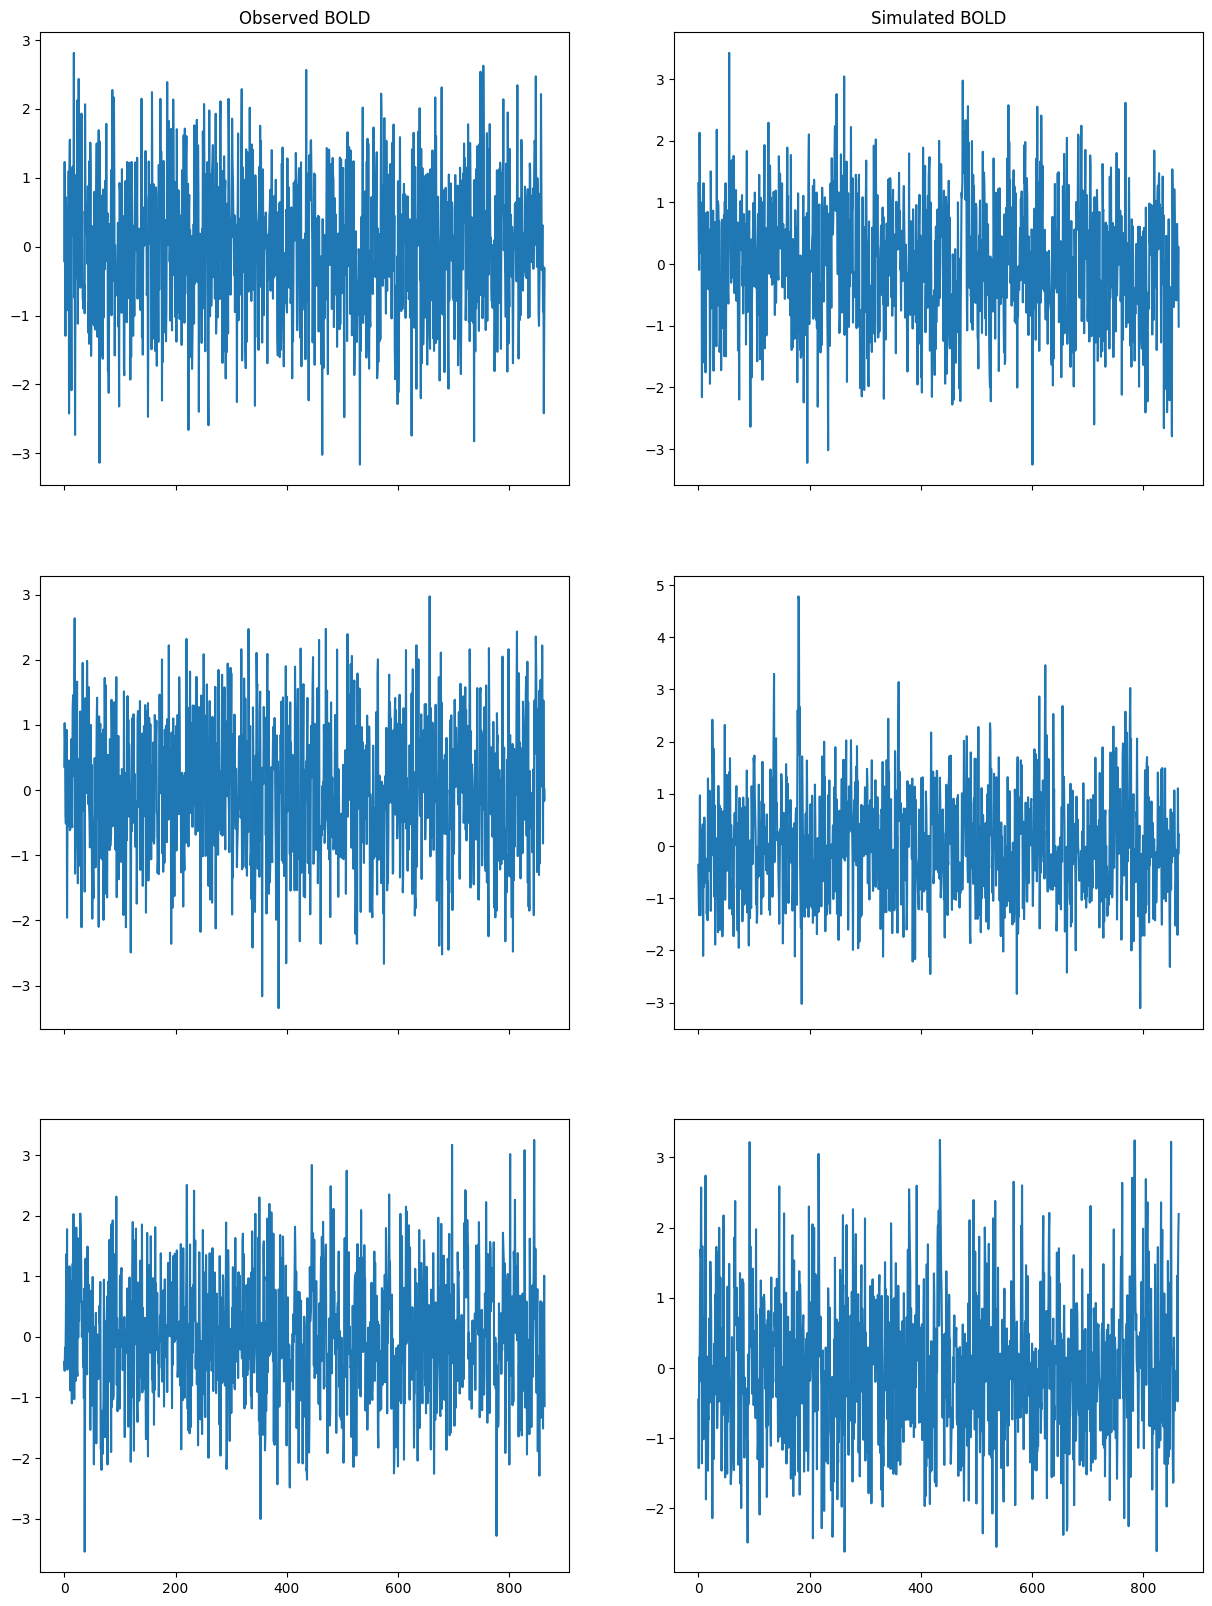

In [10]:
## look at some in the time domain 
t = torch.tensor([i*TR for i in range(y_obs.shape[1])])

## real images 
vix = [550, 1300, 23000]
f, ax = plt.subplots(3,2, figsize=(15,20), sharex=True)

ax[0,0].plot(t, y_obs_standard[vix[0],:])
ax[1,0].plot(t, y_obs_standard[vix[1],:])
ax[2,0].plot(t, y_obs_standard[vix[2],:])
ax[0,0].set_title("Observed BOLD")

ax[0,1].plot(t, y_sim_standardized[vix[0],:])
ax[1,1].plot(t, y_sim_standardized[vix[1],:])
ax[2,1].plot(t, y_sim_standardized[vix[2],:])
ax[0,1].set_title("Simulated BOLD")


Text(0.5, 1.0, 'Simulated BOLD')

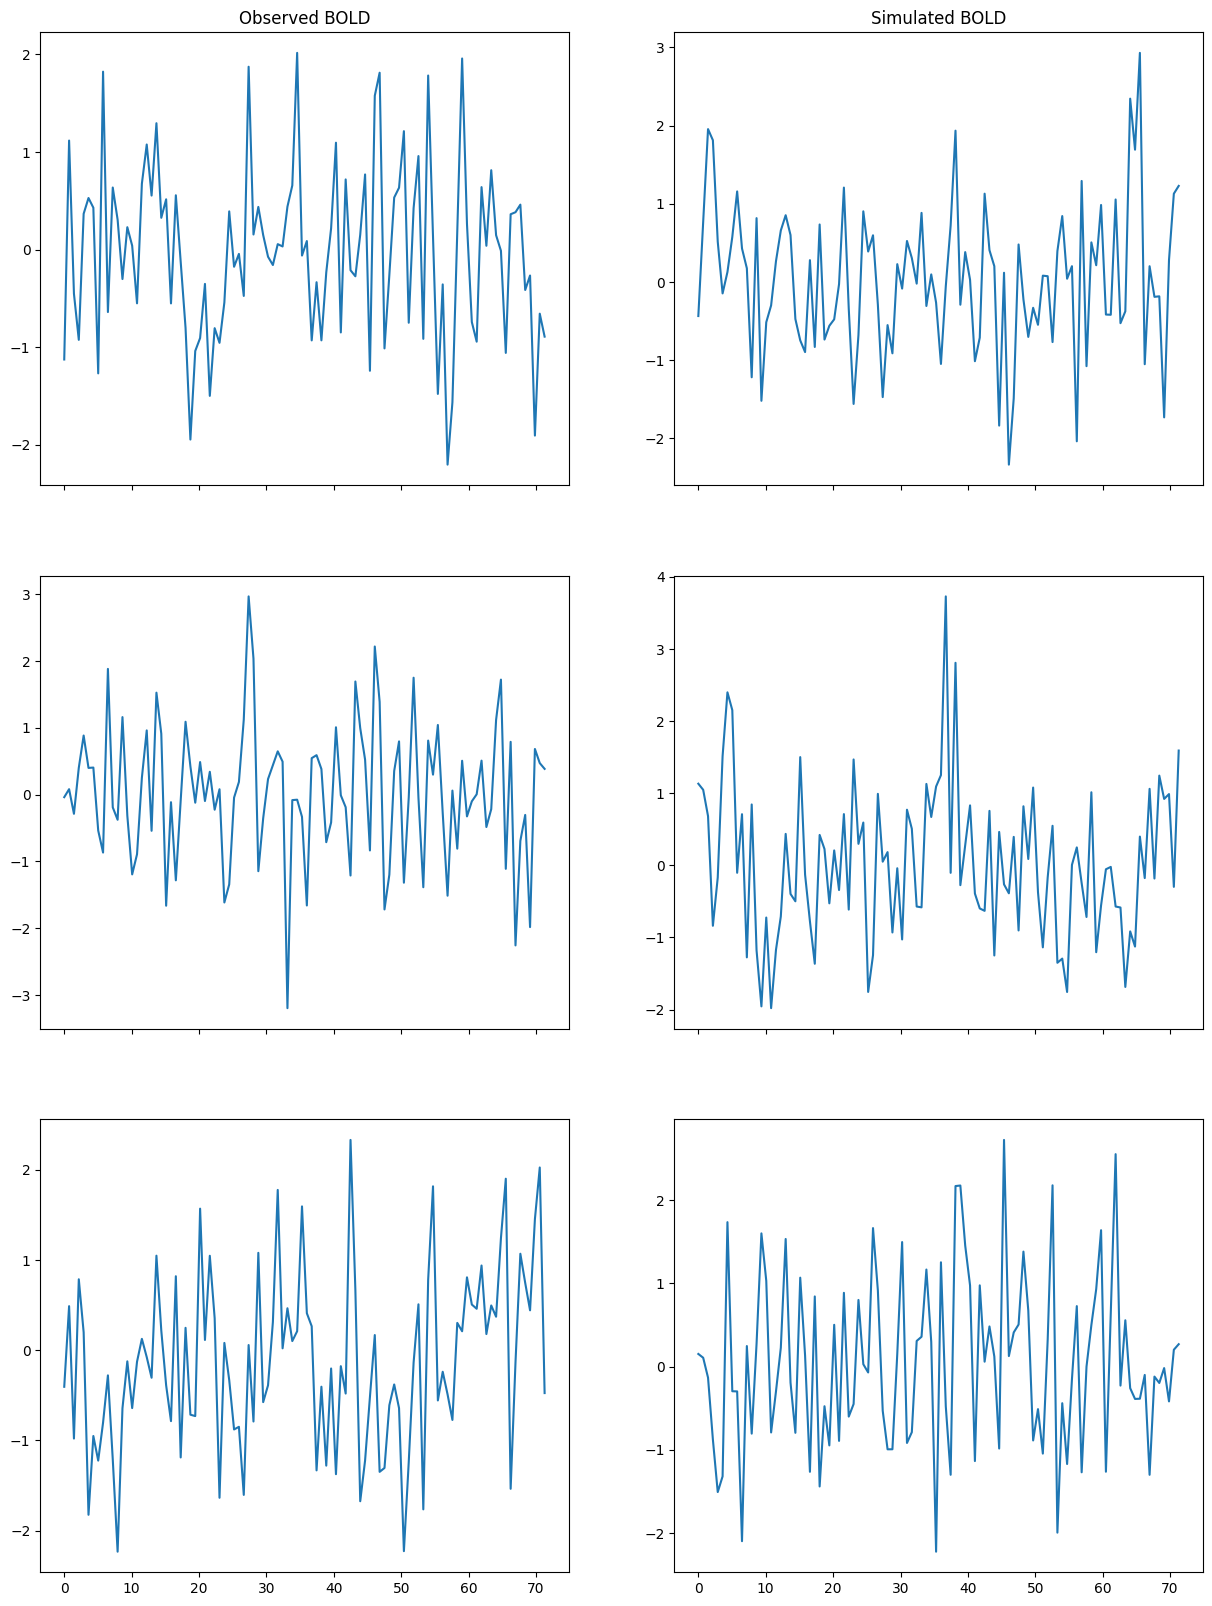

In [17]:
f, ax = plt.subplots(3,2, figsize=(15,20), sharex=True)

tmax_plt = 100

ax[0,0].plot(t[:tmax_plt], y_obs_standard[vix[0],:tmax_plt])
ax[1,0].plot(t[:tmax_plt], y_obs_standard[vix[1],:tmax_plt])
ax[2,0].plot(t[:tmax_plt], y_obs_standard[vix[2],:tmax_plt])
ax[0,0].set_title("Observed BOLD")

ax[0,1].plot(t[:tmax_plt], y_sim_standardized[vix[0],:tmax_plt])
ax[1,1].plot(t[:tmax_plt], y_sim_standardized[vix[1],:tmax_plt])
ax[2,1].plot(t[:tmax_plt], y_sim_standardized[vix[2],:tmax_plt])
ax[0,1].set_title("Simulated BOLD")

## Spectral Analysis 

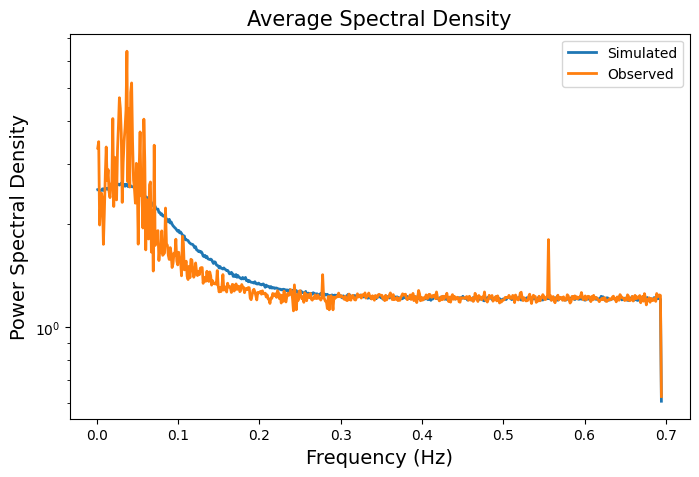

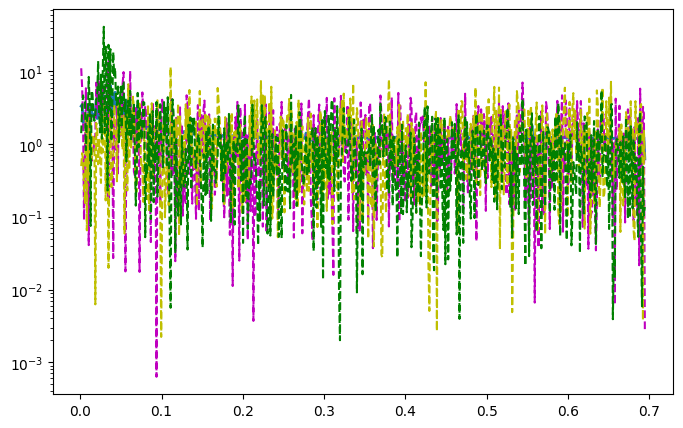

In [16]:
## Spectral analysis 
freqs_sim, psd_sim = scipy.signal.periodogram(y_sim_standardized, 1./TR, axis=-1)
freqs_obs, psd_obs = scipy.signal.periodogram(y_obs_standard, 1./TR, axis=-1)

## data is mean zero 
freqs_sim = freqs_sim[1:]; psd_sim = psd_sim[:,1:]
freqs_obs = freqs_obs[1:]; psd_obs = psd_obs[:,1:]

mean_psd_sim = psd_sim.mean(axis=0)
mean_psd_obs = psd_obs.mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(freqs_sim, mean_psd_sim, label='Simulated', lw=2)
ax.plot(freqs_obs, mean_psd_obs, label='Observed', lw=2)
ax.set_xlabel('Frequency (Hz)', fontsize=14)
ax.set_ylabel('Power Spectral Density', fontsize=14)
ax.set_title('Average Spectral Density', fontsize=15)
ax.set_yscale("log")
ax.legend()

f, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_obs, mean_psd_obs, label='Observed', lw=2)

cols = ["m","y","g"]
for i in range(3):
    ax.plot(freqs_obs, psd_obs[i,:],"--", label='Observed', c=cols[i])

ax.set_yscale("log")
    


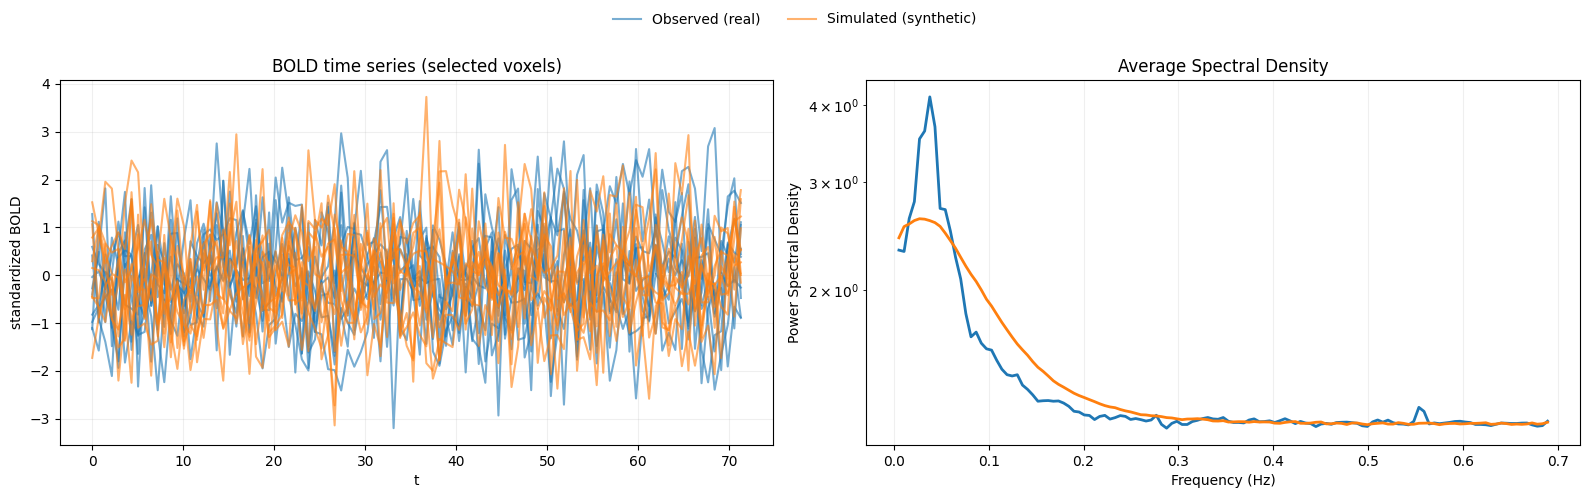

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

# assumes these exist:
# t, TR, vix, y_obs_standard, y_sim_standardized

tmax_plt = 100
t_plt = t[:tmax_plt]

real_color = "C0"
syn_color  = "C1"

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# -------------------------
# Left: time series overlay
# -------------------------
for i, vid in enumerate(vix):
    ax[0].plot(
        t_plt,
        y_obs_standard[vid, :tmax_plt],
        color=real_color,
        alpha=0.6,
        lw=1.5,
        label="Observed (real)" if i == 0 else None,
    )

for i, vid in enumerate(vix):
    ax[0].plot(
        t_plt,
        y_sim_standardized[vid, :tmax_plt],
        color=syn_color,
        alpha=0.6,
        lw=1.5,
        label="Simulated (synthetic)" if i == 0 else None,
    )

ax[0].set_title("BOLD time series (selected voxels)")
ax[0].set_xlabel("t")
ax[0].set_ylabel("standardized BOLD")
ax[0].grid(True, alpha=0.2)

# -----------------------------------
# Right: average spectral density PSD
# -----------------------------------
#freqs_sim, psd_sim = scipy.signal.periodogram(y_sim_standardized, 1.0 / TR, axis=-1)
#freqs_obs, psd_obs = scipy.signal.periodogram(y_obs_standard,  1.0 / TR, axis=-1)

# Choose segment length in samples (common: 1/4 to 1/2 of the run length)
nperseg = min(256, y_obs_standard.shape[-1])  # adjust as you like
fs = 1.0 / TR  # sampling rate (Hz)

freqs_obs, psd_obs = scipy.signal.welch(
    y_obs_standard, fs=fs, axis=-1,
    nperseg=nperseg, noverlap=nperseg//2,
    detrend=False, window="hann"
)

freqs_sim, psd_sim = scipy.signal.welch(
    y_sim_standardized, fs=fs, axis=-1,
    nperseg=nperseg, noverlap=nperseg//2,
    detrend=False, window="hann"
)

# drop DC component (mean is ~0)
freqs_sim, psd_sim = freqs_sim[1:-1], psd_sim[:, 1:-1]
freqs_obs, psd_obs = freqs_obs[1:-1], psd_obs[:, 1:-1]

mean_psd_sim = psd_sim.mean(axis=0)
mean_psd_obs = psd_obs.mean(axis=0)

ax[1].plot(freqs_obs, mean_psd_obs, label="Observed (real)",     lw=2, color=real_color)
ax[1].plot(freqs_sim, mean_psd_sim, label="Simulated (synthetic)", lw=2, color=syn_color)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Power Spectral Density")
ax[1].set_title("Average Spectral Density")
ax[1].set_yscale("log")
ax[1].grid(True, alpha=0.2)

# One legend for both panels (dedupe labels)
handles, labels = [], []
for a in ax:
    h, l = a.get_legend_handles_labels()
    handles += h
    labels += l
seen = set()
uniq_handles, uniq_labels = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        uniq_handles.append(h)
        uniq_labels.append(l)
        seen.add(l)

fig.legend(uniq_handles, uniq_labels, loc="upper center", ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
